# Data Exploration

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

df = pd.read_csv('../datasets/delivery_data.csv')

## Data Inspection

In [3]:
df.head(5)

,date,deliveries
0,2025-01-01,128
1,2025-01-02,124
2,2025-01-03,130
3,2025-01-04,97
4,2025-01-05,83


In [4]:
df.tail(5)

,date,deliveries
495,2026-05-11,203
496,2026-05-12,191
497,2026-05-13,218
498,2026-05-14,212
499,2026-05-15,208


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   date        500 non-null    str  
 1   deliveries  500 non-null    int64
dtypes: int64(1), str(1)
memory usage: 12.8 KB


Note: The date coulumn has a string datatype, must change it to datetime datatype.

In [6]:
df.describe()

,deliveries
count,500.000000
mean,153.956000
std,30.484828
min,80.000000
25%,133.000000
50%,154.000000
75%,177.250000
max,223.000000


## Data Transformation

In [7]:
df["date"] = pd.to_datetime(df["date"])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        500 non-null    datetime64[us]
 1   deliveries  500 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 7.9 KB


In [13]:
df.to_csv('../datasets/delivery_clean_data.csv', index=False)

## Visualization

In [14]:
df = pd.read_csv('../datasets/delivery_clean_data.csv')

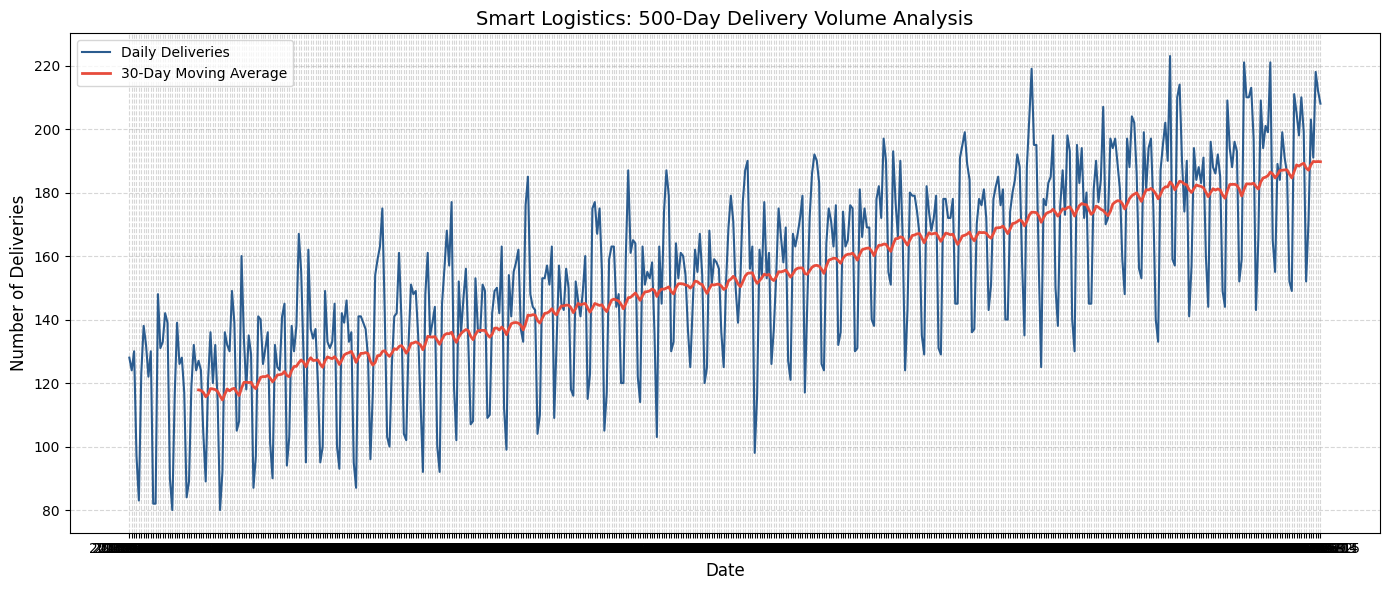

In [15]:
# Visualize the 500-day Trend
plt.figure(figsize=(14, 6))
plt.plot(
    df["date"],
    df["deliveries"],
    color="#2b5c8f",
    linewidth=1.5,
    label="Daily Deliveries",
)

# Add a rolling mean directly to Day 1 to visually highlight the trend
plt.plot(
    df["date"],
    df["deliveries"].rolling(30).mean(),
    color="#e74c3c",
    linewidth=2,
    label="30-Day Moving Average",
)

plt.title("Smart Logistics: 500-Day Delivery Volume Analysis", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Deliveries", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# Setting the date as the index for time series analysis in statsmodels
df.set_index("date", inplace=True)

print("Data loaded successfully. Ready for decomposition")

Data loaded successfully. Ready for decomposition


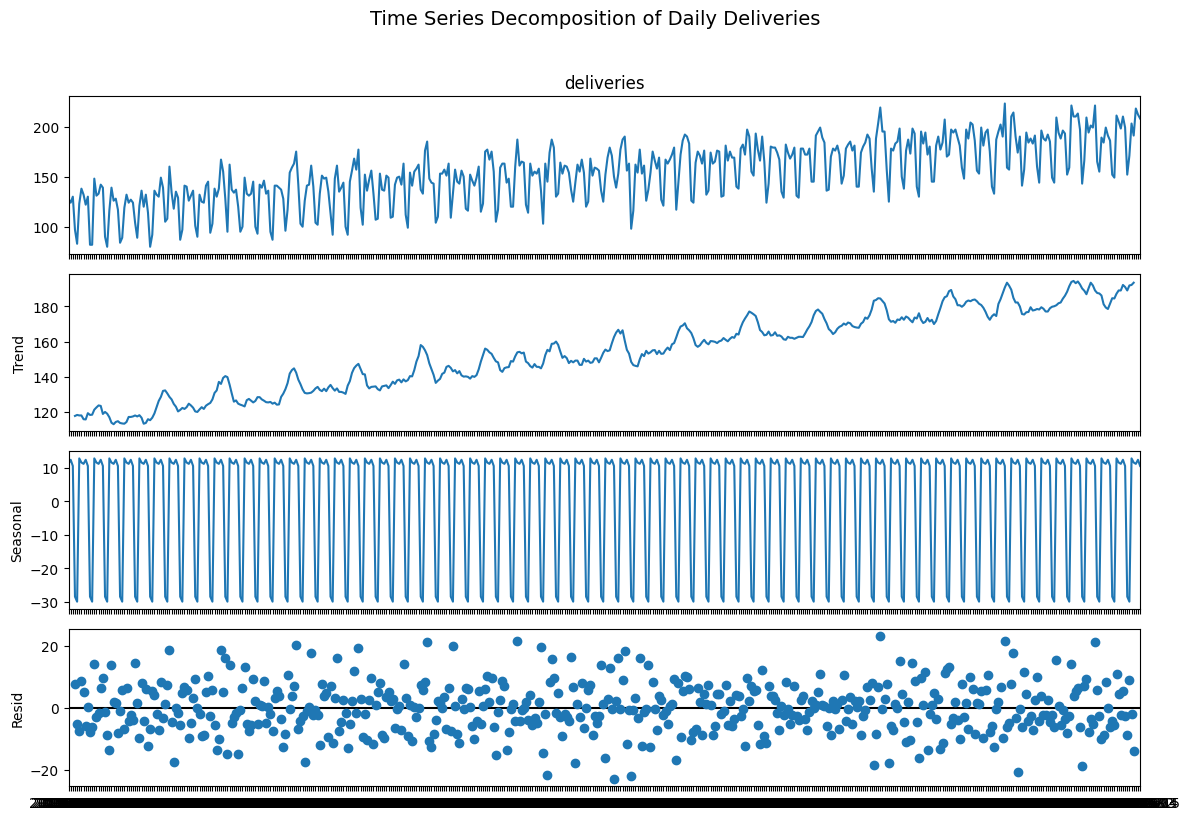

In [20]:
# 1. Perform Seasonal Decomposition (Period=7 for weekly patterns)
decomposition = seasonal_decompose(df["deliveries"], model="additive", period=7)

# 2. Plot the Components
# Customize the plot size for better visibility
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle(
    "Time Series Decomposition of Daily Deliveries", y=1.02, fontsize=14
)
plt.tight_layout()
plt.show()

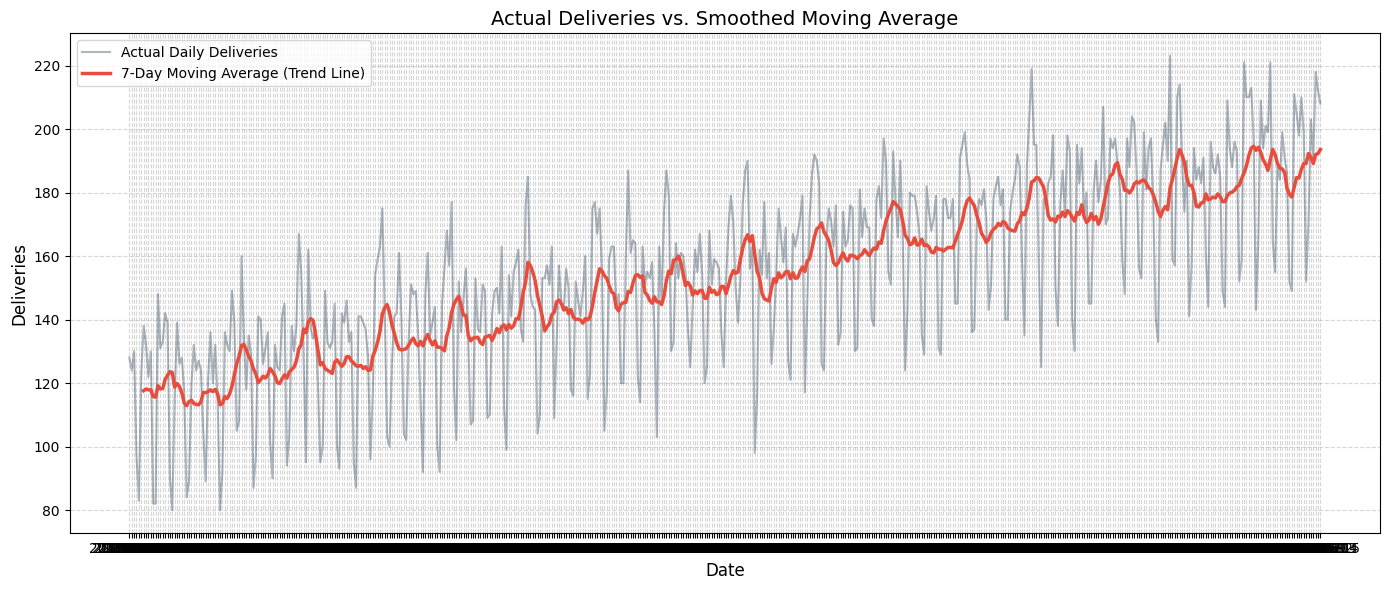

In [21]:
# Calculate 7-day moving average
df["moving_avg"] = df["deliveries"].rolling(window=7).mean()

# Visualization
plt.figure(figsize=(14, 6))
plt.plot(
    df.index,
    df["deliveries"],
    label="Actual Daily Deliveries",
    color="#34495e",
    alpha=0.4,
)
plt.plot(
    df.index,
    df["moving_avg"],
    label="7-Day Moving Average (Trend Line)",
    color="#e74c3c",
    linewidth=2.5,
)

plt.title("Actual Deliveries vs. Smoothed Moving Average", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Deliveries", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()